# 03 · The supply–demand gap  ⭐

The flagship. Notebook 02 showed where doctors *are*. This one asks where people
are *looking* for them — and finds the **gap**: high search demand meeting low
supply.

- **Supply** — *private-practice* doctors per 100k (cabinet listings + INS census).
- **Demand** — Google Search Console: impressions for care-seeking searches.

Two cuts: **geographic** (which regions are underserved) and **by specialty**
(which kinds of doctor are most over-demanded).

> **Scope — private practice only.** Every doctor here is listed at their own
> *cabinet*; doctors who work solely in **public hospitals are not counted**. So
> this measures access to *private* care. Interior/lower-income regions lean more
> on the public hospital sector, so a low private-supply score there reflects
> where private practice is viable, not the total absence of care.

> **Read the demand honestly.** GSC impressions are searches that reached
> *medline.tn specifically* — not total population demand. They're also
> confounded by supply (more doctors listed → more pages → more impressions), and
> modest in volume (~29.5k impressions / 16 months). We lean on **generic**
> queries (`cardiologue tunis`, not a doctor's name) to reduce the supply
> confound, and treat governorate-level demand as **directional**, not precise.

In [1]:
import unicodedata
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

RAW = Path('..') / 'data' / 'raw'
EXT = Path('..') / 'data' / 'external'

def strip_accents(s):
    return ''.join(c for c in unicodedata.normalize('NFD', str(s).lower())
                   if unicodedata.category(c) != 'Mn')
def norm(s):
    return ''.join(ch for ch in strip_accents(s) if ch.isalnum())

docs = pd.read_csv(RAW / 'doctors.csv')
pop  = pd.read_csv(EXT / 'population_governorate.csv')
q    = pd.read_csv(RAW / 'gsc_queries.csv')
q['nq'] = q['query'].map(strip_accents)

## 1 · Geographic gap — which regions are underserved

Supply per 100k vs **demand per 100k** (impressions of any query naming the
governorate, normalised by population). We rank both and define:

$$\text{gap} = \text{percentile-rank}(\text{demand}) - \text{percentile-rank}(\text{supply})$$

Positive = more demand than the supply rank would predict → **underserved**.

In [2]:
# supply per 100k
supply = (docs.gouvernoratSlug.value_counts()
            .rename_axis('gouvernoratSlug').rename('doctors').reset_index())
gov = pop.merge(supply, on='gouvernoratSlug', how='left')
gov['doctors'] = gov.doctors.fillna(0).astype(int)
gov['supply_per_100k'] = (gov.doctors / gov.population * 1e5).round(1)

# demand: impressions of geo-tagged queries
overrides = {'benarous': ['ben arous'], 'sidi-bouzid': ['sidi bouzid'],
             'kef': ['le kef', 'kef'], 'manouba': ['manouba', 'mannouba']}
gov_kw = {g: overrides.get(g, [g.replace('-', ' ')]) for g in gov.gouvernoratSlug}
def match_gov(s):
    for g, kws in gov_kw.items():
        if any(strip_accents(k) in s for k in kws):
            return g
    return None
q['gov'] = q.nq.map(match_gov)
demand = q[q.gov.notna()].groupby('gov').impressions.sum().rename('search_impr')
gov = gov.merge(demand, left_on='gouvernoratSlug', right_index=True, how='left')
gov['search_impr'] = gov.search_impr.fillna(0).astype(int)
gov['demand_per_100k'] = (gov.search_impr / gov.population * 1e5).round(2)

gov['gap'] = (gov.demand_per_100k.rank(pct=True)
              - gov.supply_per_100k.rank(pct=True)).round(3)
gov.sort_values('gap', ascending=False)[
    ['governorate', 'supply_per_100k', 'search_impr', 'demand_per_100k', 'gap']].head(10)

,governorate,supply_per_100k,search_impr,demand_per_100k,gap
8,Jendouba,31.9,90,22.42,0.583
9,Le Kef,36.6,50,20.56,0.375
3,Manouba,45.6,79,20.82,0.250
10,Siliana,20.2,3,1.34,0.188
11,Kairouan,34.2,33,5.78,0.167
13,Sidi Bouzid,30.0,14,3.26,0.125
23,Tataouine,29.4,2,1.34,0.104
21,Gabès,55.6,44,11.76,0.042
17,Sfax,144.4,416,43.54,0.042
14,Sousse,121.3,198,29.33,0.042


### Quadrant view

Median lines split the plane. **Bottom-right = low supply, high demand = the
desert quadrant.**

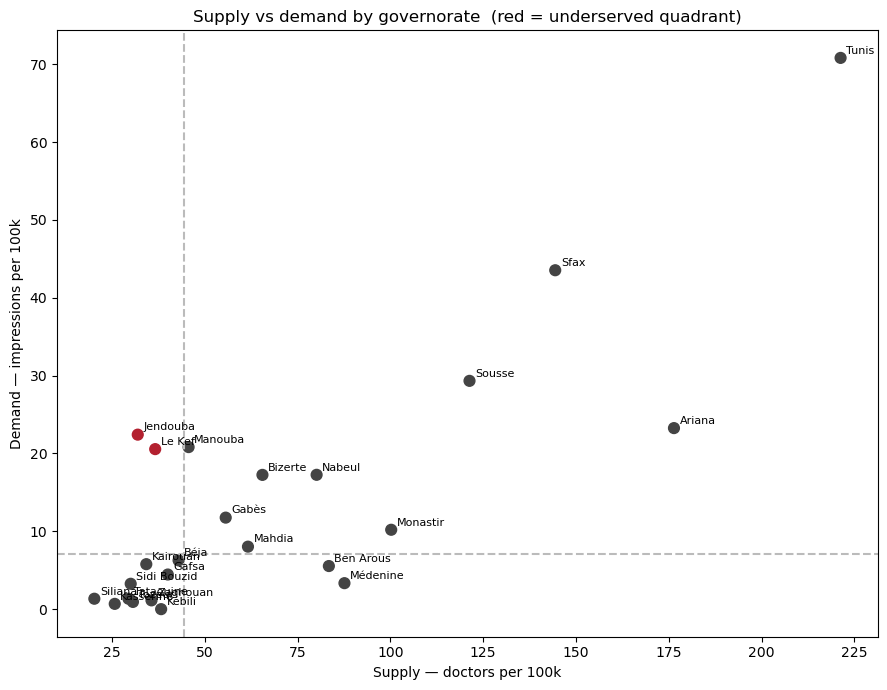

In [3]:
fig, ax = plt.subplots(figsize=(9, 7))
sx, sy = gov.supply_per_100k, gov.demand_per_100k
mx, my = sx.median(), sy.median()
colors = ['#b3202f' if (x < mx and y > my) else '#444' for x, y in zip(sx, sy)]
ax.scatter(sx, sy, c=colors, s=60)
ax.axvline(mx, ls='--', color='#bbb'); ax.axhline(my, ls='--', color='#bbb')
for _, r in gov.iterrows():
    ax.annotate(r.governorate, (r.supply_per_100k, r.demand_per_100k),
                fontsize=8, xytext=(4, 3), textcoords='offset points')
ax.set_xlabel('Supply — doctors per 100k'); ax.set_ylabel('Demand — impressions per 100k')
ax.set_title('Supply vs demand by governorate  (red = underserved quadrant)')
plt.tight_layout(); plt.show()

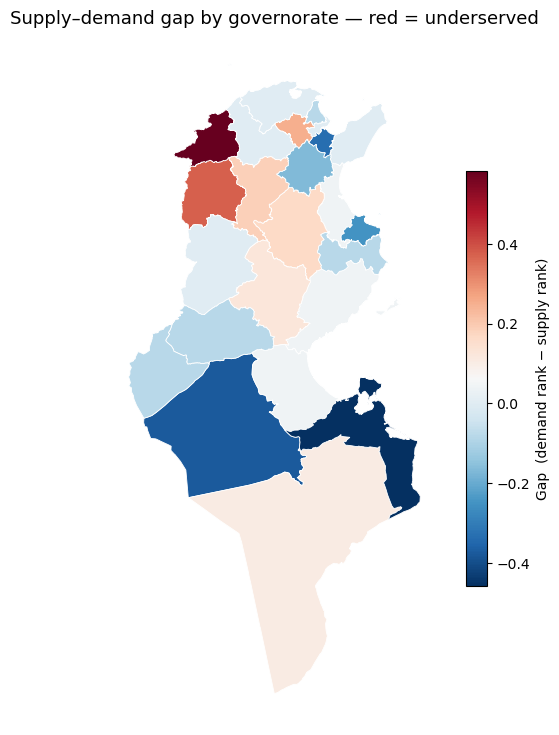

In [4]:
# Choropleth of the gap score (diverging: red = underserved)
geo_gdf = gpd.read_file(EXT / 'tunisia_governorates.geojson')
sbn = {norm(s): s for s in gov.gouvernoratSlug}
geo_gdf['gouvernoratSlug'] = geo_gdf.shapeName.map(
    lambda n: {'elkef': 'kef'}.get(norm(n)) or sbn.get(norm(n)))
gmap = geo_gdf.merge(gov, on='gouvernoratSlug')

fig, ax = plt.subplots(figsize=(8, 9))
gmap.plot(column='gap', cmap='RdBu_r', legend=True, edgecolor='white',
          linewidth=0.6, ax=ax,
          legend_kwds={'label': 'Gap  (demand rank − supply rank)', 'shrink': 0.6})
ax.set_axis_off()
ax.set_title('Supply–demand gap by governorate — red = underserved', fontsize=13)
plt.savefig('../reports/figures/gap_choropleth.png', dpi=130, bbox_inches='tight')
plt.show()

The underserved belt is the **interior north-west** — Jendouba, Le Kef, Kairouan,
Siliana — exactly the regions the density map already flagged, now confirmed to
carry real (if modest) search demand the local supply isn't meeting.

## 2 · Specialty gap — which kinds of doctor are over-demanded

Higher volume and a cleaner signal. For each specialty we match its **generic**
search term (`dermatologue`, `cardiologue`…) to its registry slug, then compare
search demand to doctor supply nationally.

**Demand pressure = impressions per doctor.** High = lots of search interest per
available provider.

In [5]:
TERM2SLUG = {
    'cardiologue': 'cardiologie', 'dermatologue': 'dermatologie',
    'pediatre': 'pediatrie', 'gynecologue': 'gynecologie-obstetrique',
    'ophtalmologue': 'ophtalmologie', 'ophtalmo': 'ophtalmologie',
    'psychiatre': 'psychiatrie', 'neurologue': 'neurologie',
    'radiologue': 'imagerie-medicale', 'urologue': 'urologie',
    'rhumatologue': 'rhumatologie', 'endocrinologue': 'endocrinologie',
    'generaliste': 'medecine-generale', 'pneumologue': 'pneumologie',
    'orthopediste': 'chirurgie-orthopedique', 'orl': 'orl',
    'gastro': 'gastro-enterologie', 'nephrologue': 'nephrologie',
}
def spec_of(s):
    for term, slug in TERM2SLUG.items():
        if term in s:
            return slug
    return None
q['spec'] = q.nq.map(spec_of)

dem = q[q.spec.notna()].groupby('spec').impressions.sum().rename('demand_impr')
sup = docs.specialtySlug.value_counts().rename('doctors')
spec = pd.concat([sup, dem], axis=1).dropna(subset=['demand_impr'])
spec['doctors'] = spec.doctors.fillna(0).astype(int)
spec['demand_per_doctor'] = (spec.demand_impr / spec.doctors).round(2)
spec['supply_share'] = spec.doctors / spec.doctors.sum()
spec['demand_share'] = spec.demand_impr / spec.demand_impr.sum()
spec = spec.sort_values('demand_per_doctor', ascending=False)
spec[['doctors', 'demand_impr', 'demand_per_doctor']]

,doctors,demand_impr,demand_per_doctor
dermatologie,279,1025.0,3.67
neurologie,143,247.0,1.73
cardiologie,380,625.0,1.64
rhumatologie,121,168.0,1.39
ophtalmologie,491,683.0,1.39
psychiatrie,225,223.0,0.99
orl,299,233.0,0.78
pneumologie,208,155.0,0.75
endocrinologie,154,104.0,0.68
urologie,186,110.0,0.59


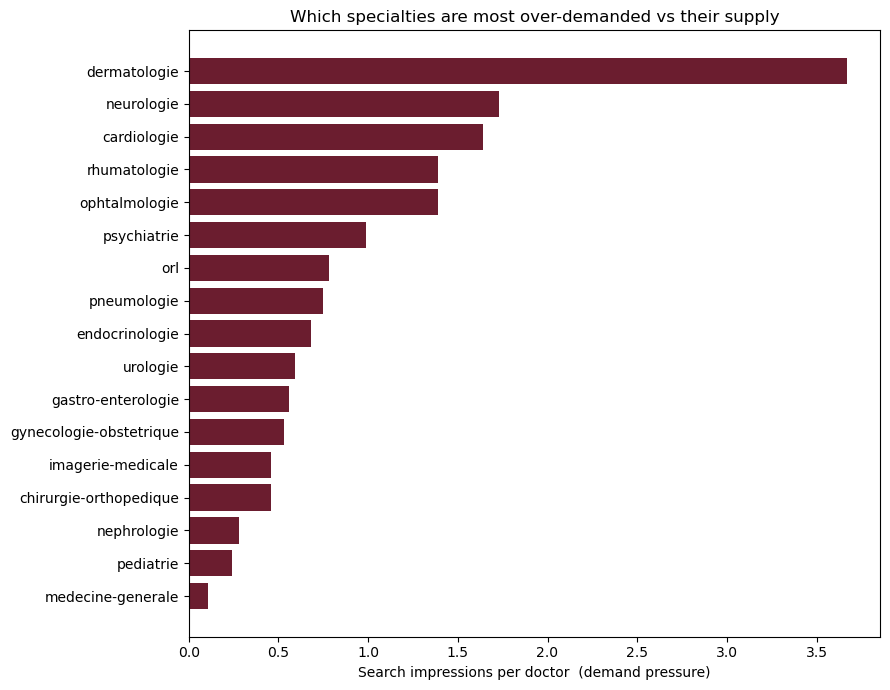

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
s = spec.sort_values('demand_per_doctor')
ax.barh(s.index, s.demand_per_doctor, color='#6B1D2F')
ax.set_xlabel('Search impressions per doctor  (demand pressure)')
ax.set_title('Which specialties are most over-demanded vs their supply')
plt.tight_layout(); plt.show()

### Supply share vs demand share

The diagonal is balance. Points **above** the line draw more of the search
demand than their share of doctors → under-supplied for the interest they pull.

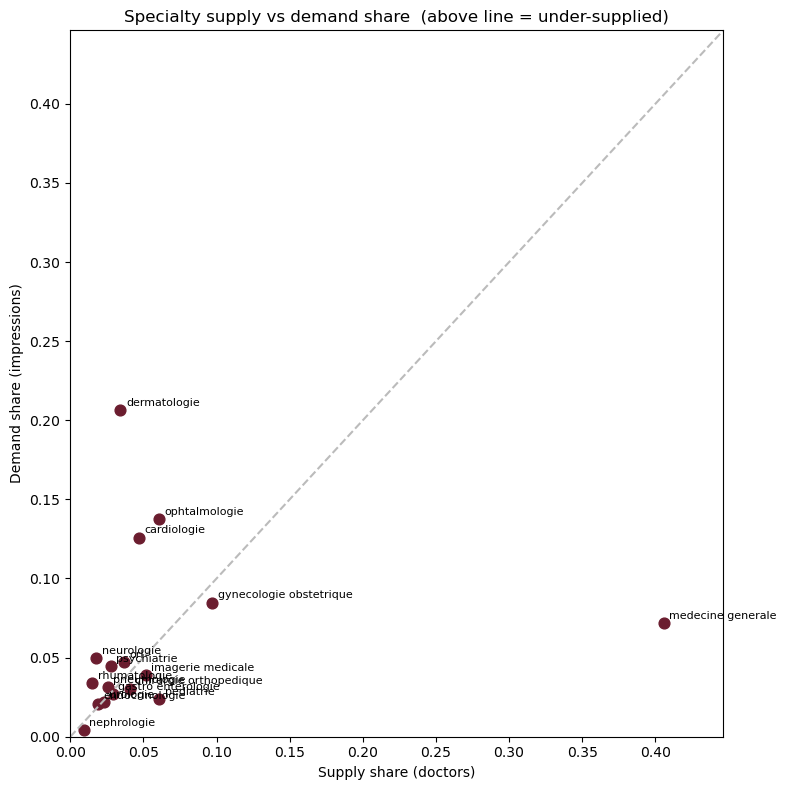

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(spec.supply_share, spec.demand_share, s=60, color='#6B1D2F')
lim = max(spec.supply_share.max(), spec.demand_share.max()) * 1.1
ax.plot([0, lim], [0, lim], ls='--', color='#bbb')
for name, r in spec.iterrows():
    ax.annotate(name.replace('-', ' '), (r.supply_share, r.demand_share),
                fontsize=8, xytext=(4, 3), textcoords='offset points')
ax.set_xlabel('Supply share (doctors)'); ax.set_ylabel('Demand share (impressions)')
ax.set_title('Specialty supply vs demand share  (above line = under-supplied)')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
plt.tight_layout(); plt.show()

## Synthesis

- **Dermatology** is the standout: ~6× more search demand than its share of
  doctors. Neurology, cardiology and ophthalmology are also over-demanded.
- **Généralistes** sit far below the line — 40% of doctors, ~7% of search
  demand — because patients don't *search* for a GP. A good sanity check that
  the signal reflects real care-seeking behaviour.
- Geographically, the **interior north-west** (Jendouba, Le Kef, Kairouan,
  Siliana) is most underserved on both supply and the supply–demand gap.

### Caveats (state these in any writeup)
- **Supply = private practice only.** These are cabinet doctors; public-hospital
  staff aren't counted, so regions that rely on public hospitals look emptier
  than their true care access. This measures *private* healthcare access.
- GSC demand = impressions on medline.tn, not a population demand census; it's
  supply-confounded and volume is modest. Treat magnitudes as directional.
- GSC drops low-volume queries (privacy threshold), so rare-specialty / small-
  governorate demand is undercounted.

### Next
1. **Delegation level** (228 zones) — sharper deserts than 24 governorates.
2. **Specialty × governorate** gap — e.g. *dermatologue Kairouan* specifically.
3. **Streamlit dashboard** — filter the gap by specialty/region (the deploy piece).